Gaussian Processes   
https://scikit-learn.org/stable/modules/gaussian_process.html

In [1]:
import numpy as np
from numpy import random as rng
from matplotlib import pyplot as plt

((1024, 2), (1024,))

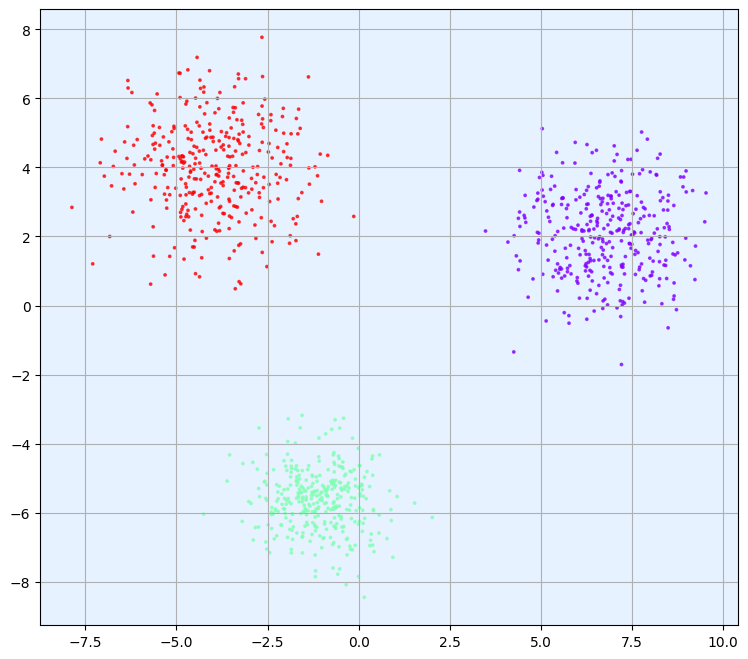

In [2]:
from sklearn.datasets import make_blobs

n_samples = 1024
n_blobs = 3 # количество кластеров

X, target = make_blobs( 
        n_samples=n_samples,
        centers=n_blobs,  
        cluster_std = rng.uniform(size=n_blobs)+.7
    )
display( (X.shape, target.shape) )

fig,ax = plt.subplots(1,figsize=(9,8))
ax.scatter(X[:,0],X[:,1],c=target, s=3,alpha=0.7,cmap='rainbow')
ax.set_facecolor('#e6f2ff')
ax.grid()
plt.show()


In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, target_train, target_test = train_test_split(X, target, test_size=0.3)
display( (X_train.shape, target_train.shape,), (X_test.shape, target_test.shape) )

((716, 2), (716,))

((308, 2), (308,))

In [ ]:
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF

model = GaussianProcessClassifier(kernel=RBF(),).fit(X_train,target_train)

In [6]:
p_train = model.predict(X_train)
p_test  = model.predict(X_test)

In [7]:
from sklearn.metrics import classification_report

# таблица метрик качества классификации на тестовом наборе
print('train:')
print( classification_report(y_true=target_train, y_pred=p_train) )

print('----------------------\ntest:')
print( classification_report(y_true=target_test, y_pred=p_test) )

train:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       237
           1       1.00      1.00      1.00       243
           2       1.00      1.00      1.00       236

    accuracy                           1.00       716
   macro avg       1.00      1.00      1.00       716
weighted avg       1.00      1.00      1.00       716

----------------------
test:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       105
           1       1.00      1.00      1.00        98
           2       1.00      1.00      1.00       105

    accuracy                           1.00       308
   macro avg       1.00      1.00      1.00       308
weighted avg       1.00      1.00      1.00       308



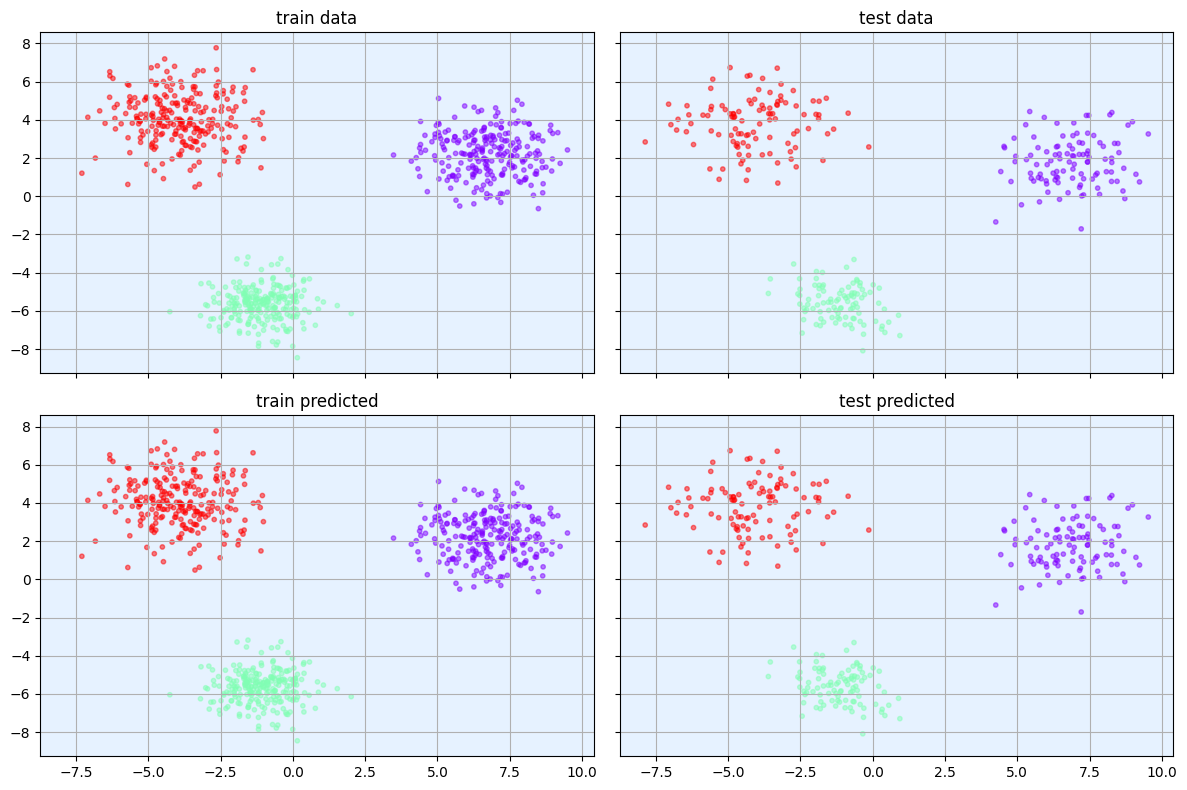

In [8]:
fig, ax = plt.subplots(2,2, sharey=True, sharex=True, figsize=(12,8),)
    
ax[0,0].scatter( x=X_train[:,0], y=X_train[:,1], c=target_train, s=10, alpha=0.5,cmap='rainbow')
ax[0,0].set_facecolor('#e6f2ff')
ax[0,0].grid()
ax[0,0].set_title('train data')

ax[0,1].scatter( x=X_test[:,0], y=X_test[:,1], c=target_test, s=10, alpha=0.5,cmap='rainbow')
ax[0,1].set_facecolor('#e6f2ff')
ax[0,1].grid()
ax[0,1].set_title('test data')

ax[1,0].scatter( x=X_train[:,0], y=X_train[:,1], c=p_train, s=10, alpha=0.5,cmap='rainbow')
ax[1,0].set_facecolor('#e6f2ff')
ax[1,0].grid()
ax[1,0].set_title('train predicted')

ax[1,1].scatter( x=X_test[:,0], y=X_test[:,1], c=p_test, s=10, alpha=0.5,cmap='rainbow')
ax[1,1].set_facecolor('#e6f2ff')
ax[1,1].grid()
ax[1,1].set_title('test predicted')

plt.tight_layout()
plt.show()